# Demonstration of the Tutorial

```
conda
cd D:\Research\Cs\FPGA_PID\Tutorial
code Tutorial_WanlinWang.ipynb

C:\Users\wwlyn\miniconda3\envs\pyrpl-wwlyn\python.exe
```

### Install my modified PyRPL

```
conda remove --name YOUR_ENV_NAME --all
conda create --name pyrpl-wwlyn python=3.9
conda activate pyrpl-wwlyn
git clone -b max_hold_no_iir_improvement https://github.com/wwlyn/pyrpl_change.git
d:
cd D:\Research\Cs\FPGA_PID\pyrpl_change
conda install netifaces
pip install .
pip install pyqt5
```

`conda install matplotlib`

In [1]:
### install 

We can change `pg.GraphicsWindow` to `pg.GraphicsLayoutWidget` to fix it.

In [2]:
# fix the numpy warning
import numpy as np
if not hasattr(np, 'VisibleDeprecationWarning'):
    np.VisibleDeprecationWarning = UserWarning
if not hasattr(np, 'ComplexWarning'):
    np.ComplexWarning = UserWarning
if not hasattr(np, "complex"):
    np.complex = complex
# other fixs already done in the source code


In [3]:
from pyrpl import Pyrpl

In [5]:
HOSTNAME = "169.254.138.46" # my Red Pitaya
p = Pyrpl(hostname=HOSTNAME)

INFO:pyrpl:Please select or create a configuration file in the file selector window!
INFO:pyrpl:All your PyRPL settings will be saved to the config file
    C:\Users\wwlyn\pyrpl_user_dir\config\0930.yml
If you would like to restart PyRPL with these settings, type "pyrpl.exe 0930" in a windows terminal or 
    from pyrpl import Pyrpl
    p = Pyrpl('0930')
in a python terminal.
INFO:pyrpl.redpitaya:Successfully connected to Redpitaya with hostname 169.254.138.46.


In [6]:
print(np.__version__)

2.0.2


Text(0, 0.5, 'Voltage')

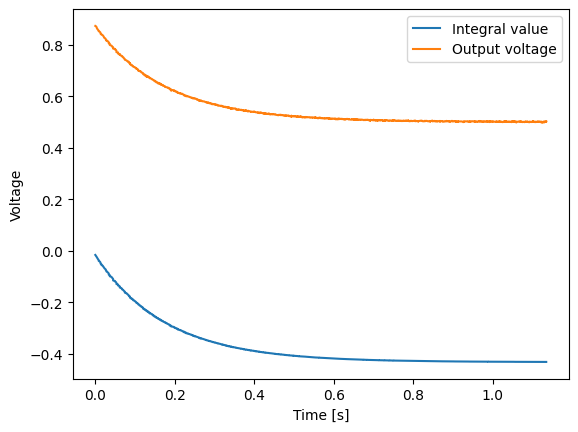

In [8]:
# Digital Setpoint
pid = p.rp.pid0

pid.input = "in1"
pid.output_direct = "out1"
pid.setpoint = 0.5
pid.ival = 0 # integral value
pid.p, pid.i = 0, -1
pid.min_voltage, pid.max_voltage = -0.99, 0.99
pid.pause_gains = "pi"
pid.paused = False


# oscilloscope
from time import time
times, ivals, outputs, inputs = [], [], [], []

for n in range(1000):
    times.append(time())
    ivals.append(pid.ival)
    outputs.append(p.rp.scope.voltage_in1)

#plot
import matplotlib.pyplot as plt
%matplotlib inline
times = np.array(times)-min(times)
plt.plot(times,ivals,times,outputs)
plt.legend(["Integral value","Output voltage","Input voltage"])
plt.xlabel("Time [s]")
plt.ylabel("Voltage")

Text(0, 0.5, 'Voltage')

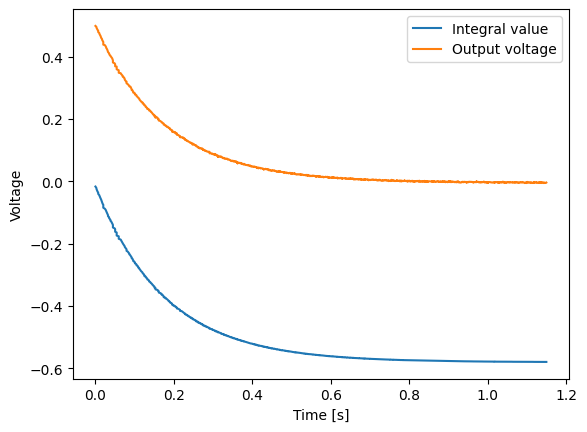

ERROR:paramiko.transport:Socket exception: 远程主机强迫关闭了一个现有的连接。 (10054)


In [9]:
# Analog Setpoint
# Dummy PID for analog setpoint
pid_dummy = p.rp.pid0
pid_dummy.input = "in2"  # Reference signal
pid_dummy.paused = True

# Main PID in differential mode
pid = p.rp.pid1
pid.input = "in1"  # Control signal
pid.output_direct = "out1"
pid.differential_mode_enabled = True  # Error = pid1.input - pid0.input
pid.ival = 0
pid.p, pid.i = 0, -1
pid.min_voltage, pid.max_voltage = -0.99, 0.99
pid.pause_gains = "pi"
pid.paused = False


# oscilloscope
from time import time
times, ivals, outputs, inputs = [], [], [], []

for n in range(1000):
    times.append(time())
    ivals.append(pid.ival)
    outputs.append(p.rp.scope.voltage_in1)

import matplotlib.pyplot as plt
%matplotlib inline
times = np.array(times)-min(times)
plt.plot(times,ivals,times,outputs)
plt.legend(["Integral value","Output voltage","Input voltage"])
plt.xlabel("Time [s]")
plt.ylabel("Voltage")

pip install pyzmq==26.4.0
python -m blacs

np.linspace(0,1,8)